In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("EDAVisualizations") \
    .master("local[4]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

sns.set_style("whitegrid")

df = spark.read.parquet("../data/processed/trips_with_disruptions")
print("Rows:", df.count())

26/07/15 12:05:07 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
                                                                                

Rows: 765089


# disruption rate by hour:

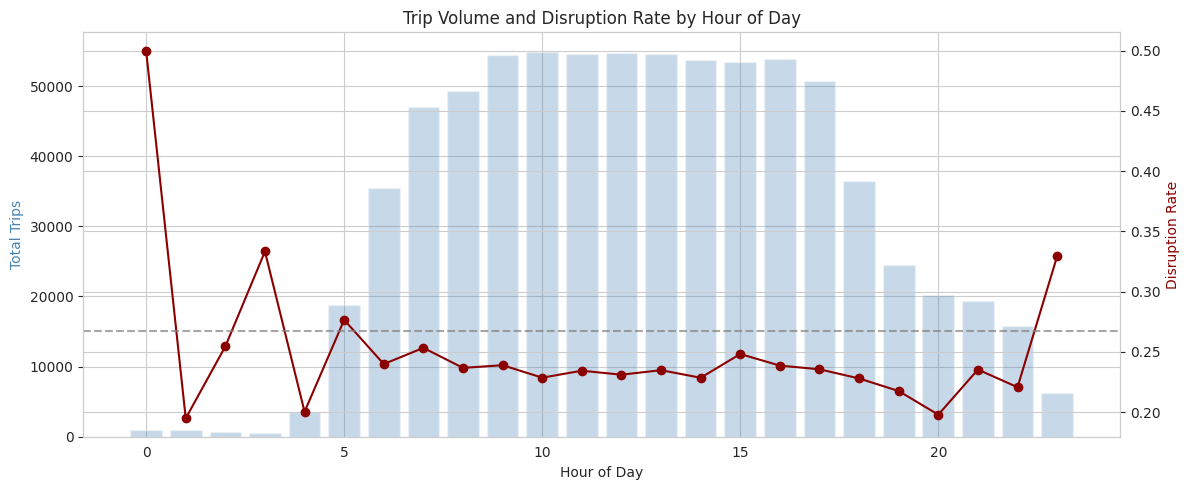

In [2]:
hourly = df.withColumn("departure_hour", F.split(F.col("departure_time"), ":")[0].cast("int")) \
    .groupBy("departure_hour").agg(
        F.count("*").alias("total_trips"),
        F.avg("is_disrupted").alias("disruption_rate")
    ).orderBy("departure_hour").toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(hourly["departure_hour"], hourly["total_trips"], alpha=0.3, color="steelblue", label="Total trips")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Total Trips", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(hourly["departure_hour"], hourly["disruption_rate"], color="darkred", marker="o", label="Disruption rate")
ax2.set_ylabel("Disruption Rate", color="darkred")
ax2.axhline(y=0.267, color="gray", linestyle="--", alpha=0.7, label="Overall average (26.7%)")

plt.title("Trip Volume and Disruption Rate by Hour of Day")
fig.tight_layout()
plt.savefig("../outputs/figures/eda_disruption_rate_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

# severity distribution:

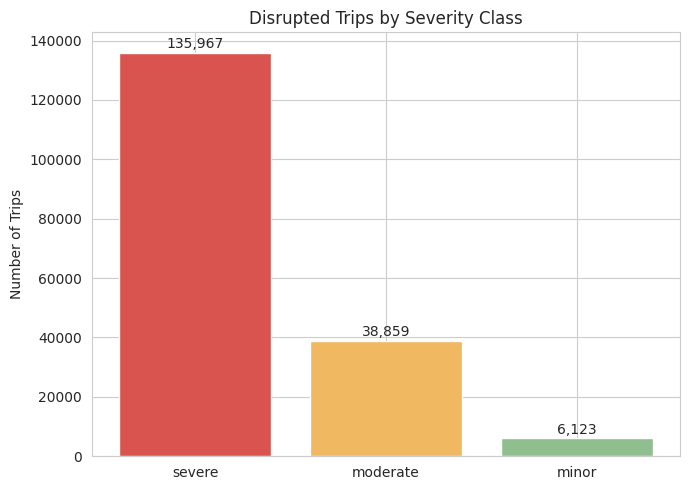

In [3]:
severity_counts = df.filter(F.col("is_disrupted") == 1).groupBy("severity").count().toPandas()

fig, ax = plt.subplots(figsize=(7, 5))
colors = {"minor": "#8fbf8f", "moderate": "#f0b860", "severe": "#d9534f"}
bar_colors = [colors[s] for s in severity_counts["severity"]]
ax.bar(severity_counts["severity"], severity_counts["count"], color=bar_colors)
ax.set_ylabel("Number of Trips")
ax.set_title("Disrupted Trips by Severity Class")
for i, v in enumerate(severity_counts["count"]):
    ax.text(i, v + 1500, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# trip volume by operator: